In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler  # Standardize features to zero mean and unit variance
from sklearn.decomposition import PCA  # Import PCA for dimensionality reduction
from sklearn.cluster import DBSCAN  # Import the DBSCAN clustering algorithm
from sklearn.neighbors import NearestNeighbors  # Find distances to nearby points
from sklearn.manifold import TSNE  # Import t-SNE for 2D visualization

In [42]:
X = np.load("artifacts/windows.npz")["X"]
metadata = pd.read_csv("artifacts/windows_meta.csv")

print(X.shape)
print(metadata.shape)

(570, 400, 5)
(570, 5)


In [43]:
data = np.load("artifacts/windows.npz")

print(data.files)

for key in data.files:
    print(key, data[key].shape)

['X', 'channels', 'fs', 'win_s', 'step_s', 'band']
X (570, 400, 5)
channels (5,)
fs ()
win_s ()
step_s ()
band (2,)


In [44]:
print(data["channels"])

['acc_vertical' 'acc_vertical_filtered' 'acc_horizontal' 'gyro_mag'
 'tacc_mag']


In [45]:
metadata = pd.read_csv("artifacts/windows_meta.csv")  # Φορτώνει τα metadata των windows
print(metadata.columns) 

Index(['window_id', 'recording_id', 'participant', 'label', 't_start'], dtype='str')


In [46]:
print(metadata["label"].value_counts())

label
bumpy     285
smooth    285
Name: count, dtype: int64


In [47]:
print(data["fs"])       # Sampling frequency
print(data["win_s"])    # Window duration
print(data["step_s"])   # Step between windows

100
4
2


In [48]:
BANDS = [(0.5, 3), (3, 8), (8, 15), (15, 30), (30, 50)]  # 5 frequency bands that will be used

time-domain feature function

In [49]:
def time_feats(x, name):
    x = x - x.mean()  # Apply zero-mean normalization
    s = x.std() + 1e-12  # Compute standard deviation and avoid division by zero

    return {
        f"{name}_std": x.std(),  # Standard deviation
        f"{name}_iqr": np.subtract(*np.percentile(x, [75, 25])),  # Interquartile range
        f"{name}_p2p": np.ptp(x),  # Peak-to-peak range: max - min
        f"{name}_p95abs": np.percentile(np.abs(x), 95),  # 95th percentile of absolute values
        f"{name}_madiff": np.abs(np.diff(x)).mean(),  # Mean absolute difference between consecutive samples
        f"{name}_kurt": ((x / s) ** 4).mean(),  # Kurtosis
        f"{name}_skew": ((x / s) ** 3).mean(),  # Skewness
        f"{name}_zcr": (np.diff(np.sign(x)) != 0).mean()  # Zero-crossing rate
    }

Frequency-domain feature function

In [50]:
def spec_feats(x, name):
    w = np.hanning(len(x))  # Apply a Hann window
    P = np.abs(np.fft.rfft((x - x.mean()) * w)) ** 2  # Compute the power spectrum
    f = np.fft.rfftfreq(len(x), 1 / 100)  # Compute the corresponding frequencies (fs = 100 Hz)

    tot = P[f >= 0.5].sum() + 1e-12  # Compute total power above 0.5 Hz
    out = {}

    for lo, hi in BANDS:
        out[f"{name}_bp{lo}-{hi}"] = P[(f >= lo) & (f < hi)].sum()  # Absolute power in each frequency band
        out[f"{name}_bf{lo}-{hi}"] = out[f"{name}_bp{lo}-{hi}"] / tot  # Fraction of total power

    p = P[f >= 0.5] / tot  # Normalize power to obtain a distribution
    out[f"{name}_centroid"] = (f[f >= 0.5] * p).sum()  # Spectral centroid
    out[f"{name}_domfreq"] = f[f >= 0.5][p.argmax()]  # Dominant frequency
    out[f"{name}_spec_entropy"] = -(p[p > 0] * np.log(p[p > 0])).sum()  # Spectral entropy

    return out  # Return all frequency-domain features

Feature Extraction per Window

In [51]:
def extract_features(w):
    ch = {c: w[:, i] for i, c in enumerate(data["channels"])}  # Map each channel name to its signal

    return (
        time_feats(ch["acc_vertical"], "vert")  # Extract time-domain features from vertical acceleration
        | time_feats(ch["acc_vertical_filtered"], "vertbp")  # Extract time-domain features from filtered vertical acceleration
        | time_feats(ch["acc_horizontal"], "horiz")  # Extract time-domain features from horizontal acceleration
        | time_feats(ch["gyro_mag"], "gyro")  # Extract time-domain features from gyroscope magnitude
        | time_feats(ch["tacc_mag"], "tacc")  # Extract time-domain features from total acceleration magnitude
        | spec_feats(ch["acc_vertical"], "vert")  # Extract frequency-domain features from vertical acceleration
        | spec_feats(ch["gyro_mag"], "gyro")  # Extract frequency-domain features from gyroscope magnitude
    )

Extract Features

In [52]:
feat = pd.DataFrame([extract_features(w) for w in data["X"]])  # Extract features from all 570 windows
FEATS = list(feat.columns)  # Store the names of all extracted features
X_features = feat.to_numpy(float)  # Convert the feature DataFrame into a NumPy array

print(f"{len(FEATS)} candidate features for {len(feat)} windows")  # Print the number of features and windows
print(X_features.shape)  # Print the shape of the resulting feature matrix

66 candidate features for 570 windows
(570, 66)


Sanity check

In [53]:
print(np.isnan(X_features).sum())  # Count all NaN values in the feature matrix
print(np.isinf(X_features).sum())  # Count all infinite values in the feature matrix

0
0


In [54]:
scaler = StandardScaler()  # Create the standardization object
X_scaled = scaler.fit_transform(X_features)  # Standardize each feature to mean 0 and standard deviation 1

print(X_scaled.shape)  # Check the shape after scaling

(570, 66)


Correlation Check

In [55]:
corr = pd.DataFrame(X_scaled, columns=FEATS).corr().abs()  # Compute absolute pairwise feature correlations
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))  # Keep only one triangle of the correlation matrix

high_corr = [
    column for column in upper.columns
    if any(upper[column] > 0.95)
]  # Find features with correlation above 0.95

print(len(high_corr))  # Print how many highly correlated features were found

16


In [56]:
print(high_corr)

['vert_p95abs', 'vertbp_iqr', 'vertbp_p2p', 'vertbp_p95abs', 'vertbp_madiff', 'horiz_p95abs', 'gyro_iqr', 'gyro_p95abs', 'tacc_std', 'tacc_iqr', 'tacc_p2p', 'tacc_p95abs', 'tacc_madiff', 'tacc_kurt', 'tacc_skew', 'tacc_zcr']


Highly Correlated Feature Pairs

In [57]:
pairs = []  # Store highly correlated feature pairs

for i in range(len(FEATS)):  # Loop over all features
    for j in range(i + 1, len(FEATS)):  # Compare each feature only with the following ones
        if corr.iloc[i, j] > 0.95:  # Check whether the correlation exceeds 0.95
            pairs.append((FEATS[i], FEATS[j], corr.iloc[i, j]))  # Store the feature pair and correlation

for pair in pairs:  # Loop through the highly correlated pairs
    print(pair)  # Display the pair and its correlation

('vert_std', 'vert_p95abs', np.float64(0.9891085659971329))
('vert_std', 'tacc_std', np.float64(0.9982726312314837))
('vert_std', 'tacc_p95abs', np.float64(0.9872309649875814))
('vert_iqr', 'tacc_iqr', np.float64(0.9983874152375907))
('vert_p2p', 'vertbp_p2p', np.float64(0.9531840170957829))
('vert_p2p', 'tacc_p2p', np.float64(0.9876557150461881))
('vert_p95abs', 'tacc_std', np.float64(0.9848164272355378))
('vert_p95abs', 'tacc_p95abs', np.float64(0.993111473137145))
('vert_madiff', 'vertbp_madiff', np.float64(0.9958282276920076))
('vert_madiff', 'tacc_madiff', np.float64(0.9990840579421882))
('vert_kurt', 'tacc_kurt', np.float64(0.9925356079503455))
('vert_skew', 'tacc_skew', np.float64(0.9637839914852339))
('vert_zcr', 'tacc_zcr', np.float64(0.9881249359841917))
('vertbp_std', 'vertbp_iqr', np.float64(0.9518936685873068))
('vertbp_std', 'vertbp_p2p', np.float64(0.95021917909473))
('vertbp_std', 'vertbp_p95abs', np.float64(0.9901311087033982))
('vertbp_madiff', 'tacc_madiff', np.float

PCA Dimensionality Reduction

In [58]:
pca = PCA(n_components=0.95)  # Keep enough principal components to explain 95% of the variance
X_pca = pca.fit_transform(X_scaled)  # Transform the standardized features into PCA space

print(X_pca.shape)  # Print the number of windows and retained PCA components
print(pca.explained_variance_ratio_.sum())  # Print the total explained variance

(570, 18)
0.954805044469322


DBSCAN

In [ ]:
dbscan = DBSCAN(eps=4, min_samples=5)  # Create the final DBSCAN model
clusters = dbscan.fit_predict(X_pca)  # Assign each window to a cluster

print(np.unique(clusters, return_counts=True))  # Display final cluster sizes

(array([-1,  0]), array([ 11, 559]))


k-distance plot

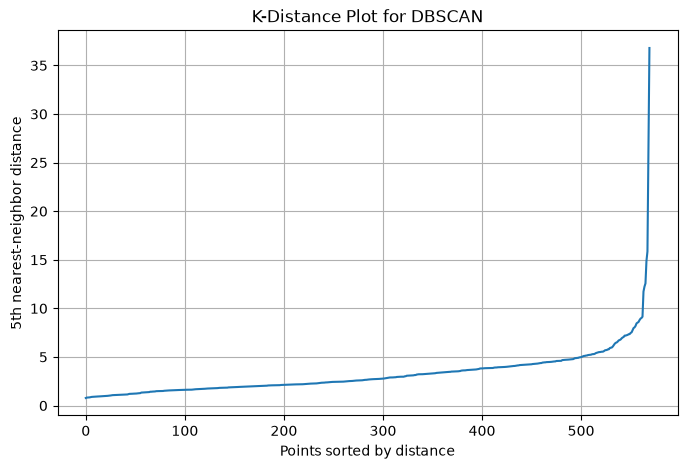

In [61]:
neighbors = NearestNeighbors(n_neighbors=5)  # Use the 5th nearest neighbor
distances, _ = neighbors.fit(X_pca).kneighbors(X_pca)  # Compute neighbor distances

k_distances = np.sort(distances[:, -1])  # Sort the 5th-neighbor distances

plt.figure(figsize=(8, 5))  # Create the plot
plt.plot(k_distances)  # Plot sorted k-distances
plt.xlabel("Points sorted by distance")  # Label x-axis
plt.ylabel("5th nearest-neighbor distance")  # Label y-axis
plt.title("K-Distance Plot for DBSCAN")  # Add plot title
plt.grid()  # Show grid
plt.show()  # Display the plot

In [64]:
for eps in [1, 1.5, 2, 2.5, 3, 3.5, 4]:  # Test several eps values
    dbscan = DBSCAN(eps=eps, min_samples=5)  # Create DBSCAN with the current eps
    labels = dbscan.fit_predict(X_pca)  # Cluster the PCA-transformed data

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)  # Count clusters excluding noise
    n_noise = np.sum(labels == -1)  # Count noise points

    print(f"eps={eps}: clusters={n_clusters}, noise={n_noise}")  # Display the result

eps=1: clusters=1, noise=534
eps=1.5: clusters=5, noise=464
eps=2: clusters=5, noise=345
eps=2.5: clusters=4, noise=267
eps=3: clusters=6, noise=203
eps=3.5: clusters=5, noise=150
eps=4: clusters=2, noise=98


In [66]:
result = metadata.copy()  # Copy metadata for cluster analysis
result["cluster"] = clusters  # Add DBSCAN cluster assignments

print(pd.crosstab(result["cluster"], result["label"]))  # Compare clusters with Bumpy/Smooth labels

label    bumpy  smooth
cluster               
-1          75      23
 0         210     233
 1           0      29


Visualization των DBSCAN clusters

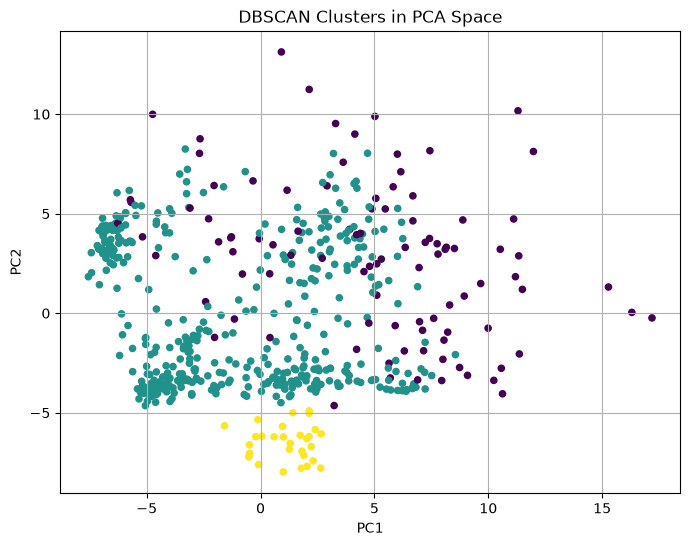

In [67]:
plt.figure(figsize=(8, 6))  # Create the plot

plt.scatter(
    X_pca[:, 0],  # First principal component
    X_pca[:, 1],  # Second principal component
    c=clusters,   # Color points according to their DBSCAN cluster
    s=20          # Set marker size
)

plt.xlabel("PC1")  # Label x-axis
plt.ylabel("PC2")  # Label y-axis
plt.title("DBSCAN Clusters in PCA Space")  # Add plot title
plt.grid()  # Show grid
plt.show()  # Display the plot

t-SNE

In [69]:
tsne = TSNE(
    n_components=2,  # Reduce the data to two dimensions
    random_state=42,  # Make the result reproducible
    perplexity=30  # Set the balance between local and global structure
)

X_tsne = tsne.fit_transform(X_pca)  # Compute the 2D t-SNE representation

print(X_tsne.shape)  # Check the resulting shape

(570, 2)


t-SNE visualization

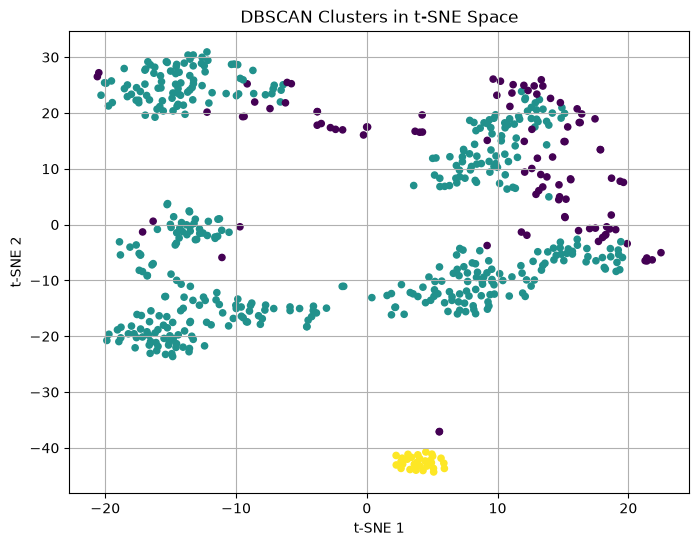

In [70]:
plt.figure(figsize=(8, 6))  # Create the plot

plt.scatter(
    X_tsne[:, 0],  # First t-SNE dimension
    X_tsne[:, 1],  # Second t-SNE dimension
    c=clusters,  # Color points according to DBSCAN cluster
    s=20  # Set marker size
)

plt.xlabel("t-SNE 1")  # Label x-axis
plt.ylabel("t-SNE 2")  # Label y-axis
plt.title("DBSCAN Clusters in t-SNE Space")  # Add plot title
plt.grid()  # Show grid
plt.show()  # Display the plot

Cluster Label Distribution

In [71]:
cluster_table = pd.crosstab(
    result["cluster"],  # DBSCAN cluster
    result["label"],
    normalize="index"  # Convert counts to percentages within each cluster
) * 100

print(cluster_table.round(1))  # Display percentages for each cluster

label    bumpy  smooth
cluster               
-1        76.5    23.5
 0        47.4    52.6
 1         0.0   100.0


t-SNE Visualization by Surface Label

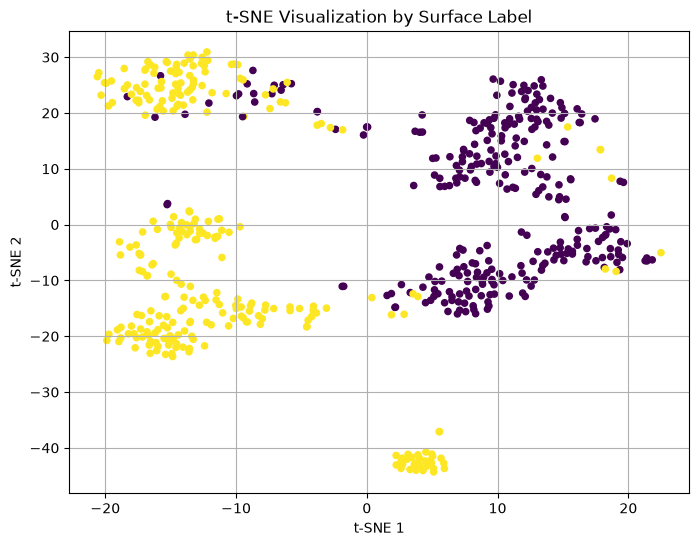

In [72]:
plt.figure(figsize=(8, 6))  # Create the plot

colors = metadata["label"].map({"bumpy": 0, "smooth": 1})  # Convert labels to numeric values

plt.scatter(
    X_tsne[:, 0],  # First t-SNE dimension
    X_tsne[:, 1],  # Second t-SNE dimension
    c=colors,  # Color points according to surface label
    s=20  # Set marker size
)

plt.xlabel("t-SNE 1")  # Label x-axis
plt.ylabel("t-SNE 2")  # Label y-axis
plt.title("t-SNE Visualization by Surface Label")  # Add plot title
plt.grid()  # Show grid
plt.show()  # Display the plot

DBSCAN min_samples Sensitivity

In [73]:
for min_samples in [3, 5, 10, 15]:  # Test different minimum neighborhood sizes
    dbscan = DBSCAN(eps=4, min_samples=min_samples)  # Keep eps fixed at 4
    labels = dbscan.fit_predict(X_pca)  # Run DBSCAN

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)  # Count clusters excluding noise
    n_noise = np.sum(labels == -1)  # Count noise points

    print(
        f"min_samples={min_samples}: clusters={n_clusters}, noise={n_noise}"
    )  # Display the result

min_samples=3: clusters=4, noise=79
min_samples=5: clusters=2, noise=98
min_samples=10: clusters=2, noise=121
min_samples=15: clusters=5, noise=136


(array([-1,  0,  1]), array([ 98, 443,  29]))
